# Oppgave 1: (10 poeng)

**1a) Les inn grunnkretser for Trondheim**

* Les inn filen `Grunnkretser 2024.geojson` og lagre den i en variabel som heter `grunnkretser`.
* Sørg for at du har lest inn en GeoDataFrame med korrekt crs.

In [1]:
# Imports
import pathlib
import mapclassify as mc
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

In [2]:
# SKRIV DIN KODE HER OG FJERN LINJEN "raise NotImplementedError()"

NOTEBOOK_PATH = pathlib.Path().resolve()
DATA_MAPPE = NOTEBOOK_PATH / "data"

grunnkretser = gpd.read_file(DATA_MAPPE / "Grunnkretser 2024.geojson")      # Leser inn "Grunnkretser 2024.geojson" til en GeoDataFrame.
grunnkretser.head()

,objtype,grunnkretsnummer,grunnkretsnavn,kommunenummer,geometry
0,Grunnkrets,50014103,Lerkendal syd,5001,"MULTIPOLYGON (((10.40079 63.41298, 10.40188 63..."
1,Grunnkrets,50011404,Rosenborg 4,5001,"MULTIPOLYGON (((10.40739 63.4347, 10.40575 63...."
2,Grunnkrets,50011607,Moen,5001,"MULTIPOLYGON (((10.44891 63.4529, 10.44884 63...."
3,Grunnkrets,50012209,Jakobsli 9,5001,"MULTIPOLYGON (((10.48434 63.42444, 10.48432 63..."
4,Grunnkrets,50017507,Heimdal 7,5001,"MULTIPOLYGON (((10.3427 63.36189, 10.34271 63...."


In [3]:
grunnkretser.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [4]:
# TEST-CELLE
## Ikke slett denne cellen, og nye kodeceller du lager til denne deloppgaven skal komme før denne!
import pandas
import geopandas
assert isinstance(grunnkretser, geopandas.GeoDataFrame), "Har du lest inn GeoDataFramen riktig?"

**1b) Les inn befolkningstall for Trondheim**

* Les inn befolkningstall for Trondheim fra filen `TRD-folkemengde.csv` i data-mappen inn i en DataFrame. NB. denne filen inneholder ikke geografisk informasjon.
* Lagre befolkningstallen i en variabel med navn `befolkning`.
* Endre navnet på kolonnen som inneholder navn på grunnkretser til å være det samme som i `grunnkretser`-GeoDataFramen. (Du kan f.eks. bruke [`.rename()`-funksjonen](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.rename.html))

In [5]:
# SKRIV DIN KODE HER OG FJERN LINJEN "raise NotImplementedError()"

befolkning = pd.read_csv(DATA_MAPPE / "TRD-folkemengde.csv")                        # Leser inn TRD-folkemengde.csv til en DataFrame.
befolkning = befolkning.rename(columns={"Grunnkretsnavn" : "grunnkretsnavn"})       # Endrer kolonnenavn fra 'Grunnkretsnavn' til 'grunnkretsnavn'.
befolkning.head()

,Unnamed: 0,Nr,grunnkretsnavn,2022,2023,2024
0,0,0.0,Uoppgitt,287,247,225
1,1,101.0,Lysklett,350,345,362
2,2,102.0,Rønningen,241,240,235
3,3,103.0,Tanem,1423,1434,1429
4,4,104.0,Lilleugla,2969,2986,2977


In [6]:
# TEST-CELLE
## Ikke slett denne cellen, og nye kodeceller du lager til denne deloppgaven skal komme før denne!
assert isinstance(befolkning, pandas.DataFrame), "Har du lest inn befolkningstallene riktig?"

**1c) Koble sammen grunnkretser og befolkningstall**

Du skal nå koble sammen grunnkretsene med befolkningstallene. Du skal sitte igjen med en GeoDataFrame som inneholder alle grunnkretsene og befolkningstall for alle årene. Lagre den sammenslåtte dataen i en GeoDataFrame som heter `grunnkretser_befolkning`.

In [7]:
# SKRIV DIN KODE HER OG FJERN LINJEN "raise NotImplementedError()"

grunnkretser_befolkning = grunnkretser.merge(befolkning, on="grunnkretsnavn")   # Sammenkobler grunnkretsene med befolkningstallene.
grunnkretser_befolkning.head()

,objtype,grunnkretsnummer,grunnkretsnavn,kommunenummer,geometry,Unnamed: 0,Nr,2022,2023,2024
0,Grunnkrets,50014103,Lerkendal syd,5001,"MULTIPOLYGON (((10.40079 63.41298, 10.40188 63...",217,4103.0,3,4,2
1,Grunnkrets,50011404,Rosenborg 4,5001,"MULTIPOLYGON (((10.40739 63.4347, 10.40575 63....",69,1404.0,490,492,486
2,Grunnkrets,50011607,Moen,5001,"MULTIPOLYGON (((10.44891 63.4529, 10.44884 63....",112,1607.0,3,7,3
3,Grunnkrets,50012209,Jakobsli 9,5001,"MULTIPOLYGON (((10.48434 63.42444, 10.48432 63...",146,2209.0,615,616,617
4,Grunnkrets,50017507,Heimdal 7,5001,"MULTIPOLYGON (((10.3427 63.36189, 10.34271 63....",407,7507.0,1096,1087,1102


In [9]:
# TEST-CELLE
## Ikke slett denne cellen, og nye kodeceller du lager til denne deloppgaven skal komme før denne!
assert isinstance(grunnkretser_befolkning, geopandas.GeoDataFrame), "Har du lest inn GeoDataFramen riktig?"

**1d) Klassifiser dataene**

Du skal nå klassifisere befolkningsdataene for 2024 i det sammenslåtte datasettet:
* Lag en `UserDefined` klassifiserer ved hjelp av [mapclassify](https://github.com/pysal/mapclassify#userdefined) og bruk klasseneskillene `250,500,1000,2000`
* Bruk klassifisereren din på kolonnen med befolkningsdata for 2024 og lagre det i en kolonnen med navn `2024_klasser`.


In [10]:
# SKRIV DIN KODE HER OG FJERN LINJEN "raise NotImplementedError()"

klassifiserer = mc.UserDefined(y=grunnkretser_befolkning["2024"], bins=[250, 500, 1000, 2000])      # Klassifiserer grunnkretsene for befolkningsdataene fra 2024
grunnkretser_befolkning["2024_klasser"] = klassifiserer.yb                                          # Legger til kolonnen '2024_klasser' i GeoDataFrame-en med grunnkretsenes klasseverdi.
grunnkretser_befolkning.head(10)

,objtype,grunnkretsnummer,grunnkretsnavn,kommunenummer,geometry,Unnamed: 0,Nr,2022,2023,2024,2024_klasser
0,Grunnkrets,50014103,Lerkendal syd,5001,"MULTIPOLYGON (((10.40079 63.41298, 10.40188 63...",217,4103.0,3,4,2,0
1,Grunnkrets,50011404,Rosenborg 4,5001,"MULTIPOLYGON (((10.40739 63.4347, 10.40575 63....",69,1404.0,490,492,486,1
2,Grunnkrets,50011607,Moen,5001,"MULTIPOLYGON (((10.44891 63.4529, 10.44884 63....",112,1607.0,3,7,3,0
3,Grunnkrets,50012209,Jakobsli 9,5001,"MULTIPOLYGON (((10.48434 63.42444, 10.48432 63...",146,2209.0,615,616,617,2
4,Grunnkrets,50017507,Heimdal 7,5001,"MULTIPOLYGON (((10.3427 63.36189, 10.34271 63....",407,7507.0,1096,1087,1102,3
5,Grunnkrets,50015106,Havstad,5001,"MULTIPOLYGON (((10.35058 63.40997, 10.35034 63...",295,5106.0,754,775,869,2
6,Grunnkrets,50015212,Storhaugen,5001,"MULTIPOLYGON (((10.34188 63.40521, 10.34034 63...",316,5212.0,875,886,867,2
7,Grunnkrets,50017409,Tiller-Hårstad 9,5001,"MULTIPOLYGON (((10.37963 63.37037, 10.37927 63...",385,7409.0,0,0,0,0
8,Grunnkrets,50012305,Ranheim 5,5001,"MULTIPOLYGON (((10.52338 63.4266, 10.52333 63....",159,2305.0,1100,1102,1140,3
9,Grunnkrets,50015119,Bymarka,5001,"MULTIPOLYGON (((10.25181 63.42052, 10.24938 63...",307,5119.0,1,1,0,0


In [11]:
klassifiserer

UserDefined

     Interval        Count
--------------------------
[   0.00,  250.00] |   153
( 250.00,  500.00] |   107
( 500.00, 1000.00] |   131
(1000.00, 2000.00] |    40
(2000.00, 2977.00] |     3

In [12]:
# TEST-CELLE
## Ikke slett denne cellen, og nye kodeceller du lager til denne deloppgaven skal komme før denne!
assert '2024_klasser' in grunnkretser_befolkning.columns, "Kolonnen '2024_klasser' finnes ikke i 'grunnkretser_befolkning'"

**1e) Plot de klassifiserte befolkningsdataene**

Lag et enkelt plot over befolkningsdataene basert på den nye klassifiseringen.

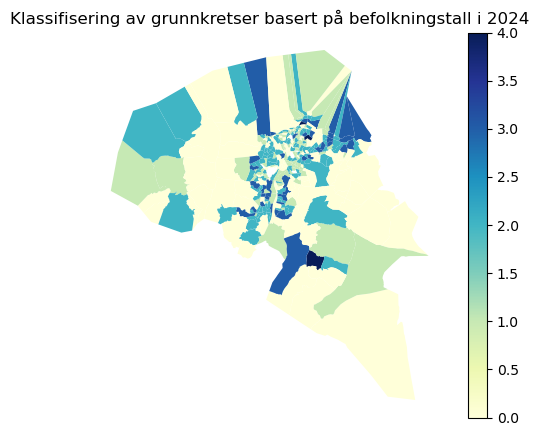

In [13]:
# SKRIV DIN KODE HER OG FJERN LINJEN "raise NotImplementedError()"

# Plotter kart 
fig, ax = plt.subplots(figsize=(6, 5))
grunnkretser_befolkning.plot(column="2024_klasser", linewidth=0, legend=True, cmap="YlGnBu", ax=ax)
ax.set_title("Klassifisering av grunnkretser basert på befolkningstall i 2024")
ax.set_axis_off()

In [14]:
# TEST-CELLE
## Ikke slett denne cellen, og nye kodeceller du lager til denne deloppgaven skal komme før denne!


## Valgfri bonusoppgave (*1 poeng*):
Lag det samme kartet for årene 2022 og 2023 og plot et histogram over den egendefinerte klassifiseringen for hvert av de tre årene.

In [15]:
klassifiserer = mc.UserDefined(y=grunnkretser_befolkning["2022"], bins=[250, 500, 1000, 2000])      # Klassifiserer grunnkretsene for befolkningsdataene fra 2022
grunnkretser_befolkning["2022_klasser"] = klassifiserer.yb                                          # Legger til kolonnen '2022_klasser' i GeoDataFrame-en med grunnkretsenes klasseverdi.

In [16]:
klassifiserer = mc.UserDefined(y=grunnkretser_befolkning["2023"], bins=[250, 500, 1000, 2000])      # Klassifiserer grunnkretsene for befolkningsdataene fra 2023
grunnkretser_befolkning["2023_klasser"] = klassifiserer.yb                                          # Legger til kolonnen '2023_klasser' i GeoDataFrame-en med grunnkretsenes klasseverdi.

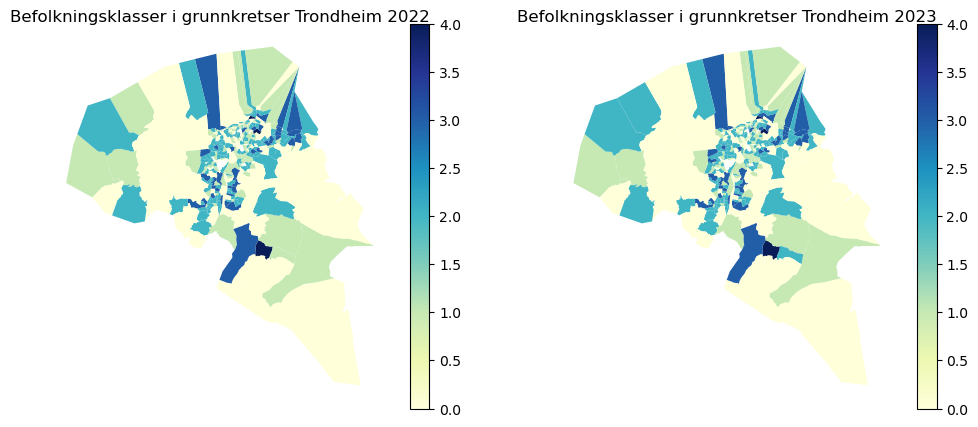

In [17]:
# Plotter befolkningsdataene i henholdsvis 2022 og 2023.
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
grunnkretser_befolkning.plot(column="2022_klasser", linewidth=0, legend=True, cmap="YlGnBu", ax=ax[0])
grunnkretser_befolkning.plot(column="2023_klasser", linewidth=0, legend=True, cmap="YlGnBu", ax=ax[1])
ax[0].set_title("Befolkningsklasser i grunnkretser Trondheim 2022")
ax[0].set_axis_off()
ax[1].set_title("Befolkningsklasser i grunnkretser Trondheim 2023")
ax[1].set_axis_off()

<Axes: title={'center': 'Klassefordeling av grunnkretser i 2024'}, xlabel='Klasse', ylabel='Antall'>

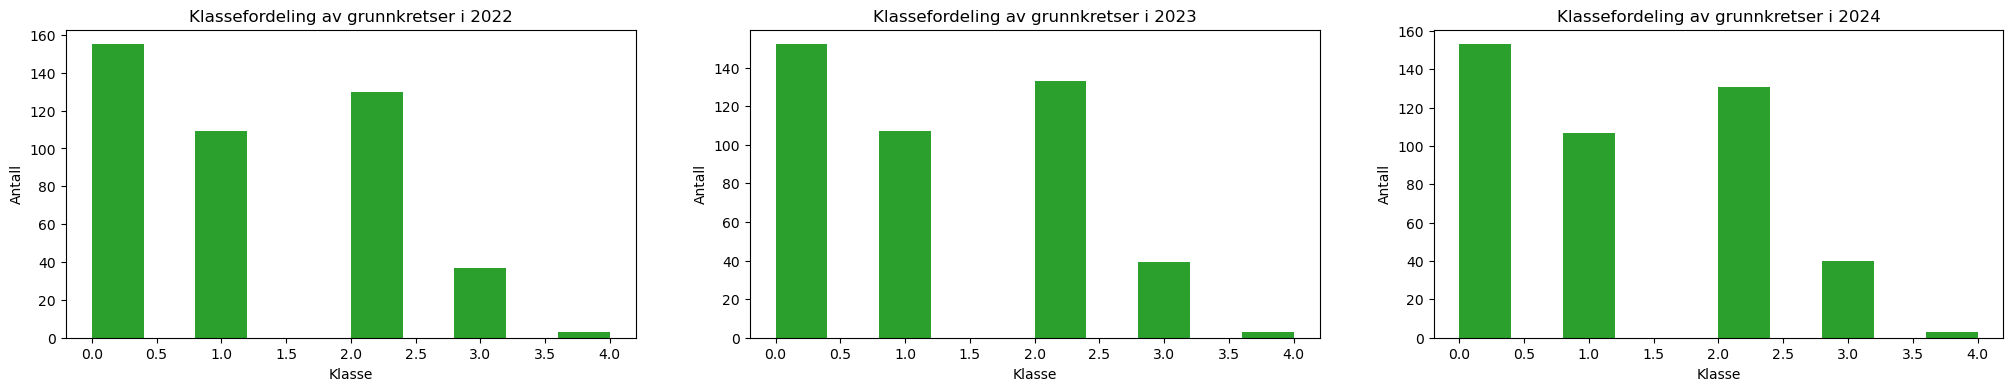

In [19]:
# Plotter histogram over de egendefinerte klassifiseringene for 2022, 2023 og 2024.
fig, ax = plt.subplots(1, 3, figsize=(25, 4))
grunnkretser_befolkning["2022_klasser"].plot.hist(title="Klassefordeling av grunnkretser i 2022", xlabel="Klasse", ylabel="Antall", color="tab:green",  ax=ax[0])
grunnkretser_befolkning["2023_klasser"].plot.hist(title="Klassefordeling av grunnkretser i 2023", xlabel="Klasse", ylabel="Antall", color="tab:green", ax=ax[1])
grunnkretser_befolkning["2024_klasser"].plot.hist(title="Klassefordeling av grunnkretser i 2024", xlabel="Klasse", ylabel="Antall", color="tab:green", ax=ax[2])